## Resume Screening 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
import nltk


In [3]:
df = pd.read_csv("./UpdatedResumeDataSet.csv")


In [4]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [5]:
df.Category.unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [6]:
len(df.Category.unique())

25

In [7]:
df.Category.value_counts()

Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: Category, dtype: int64

<AxesSubplot: xlabel='count', ylabel='Category'>

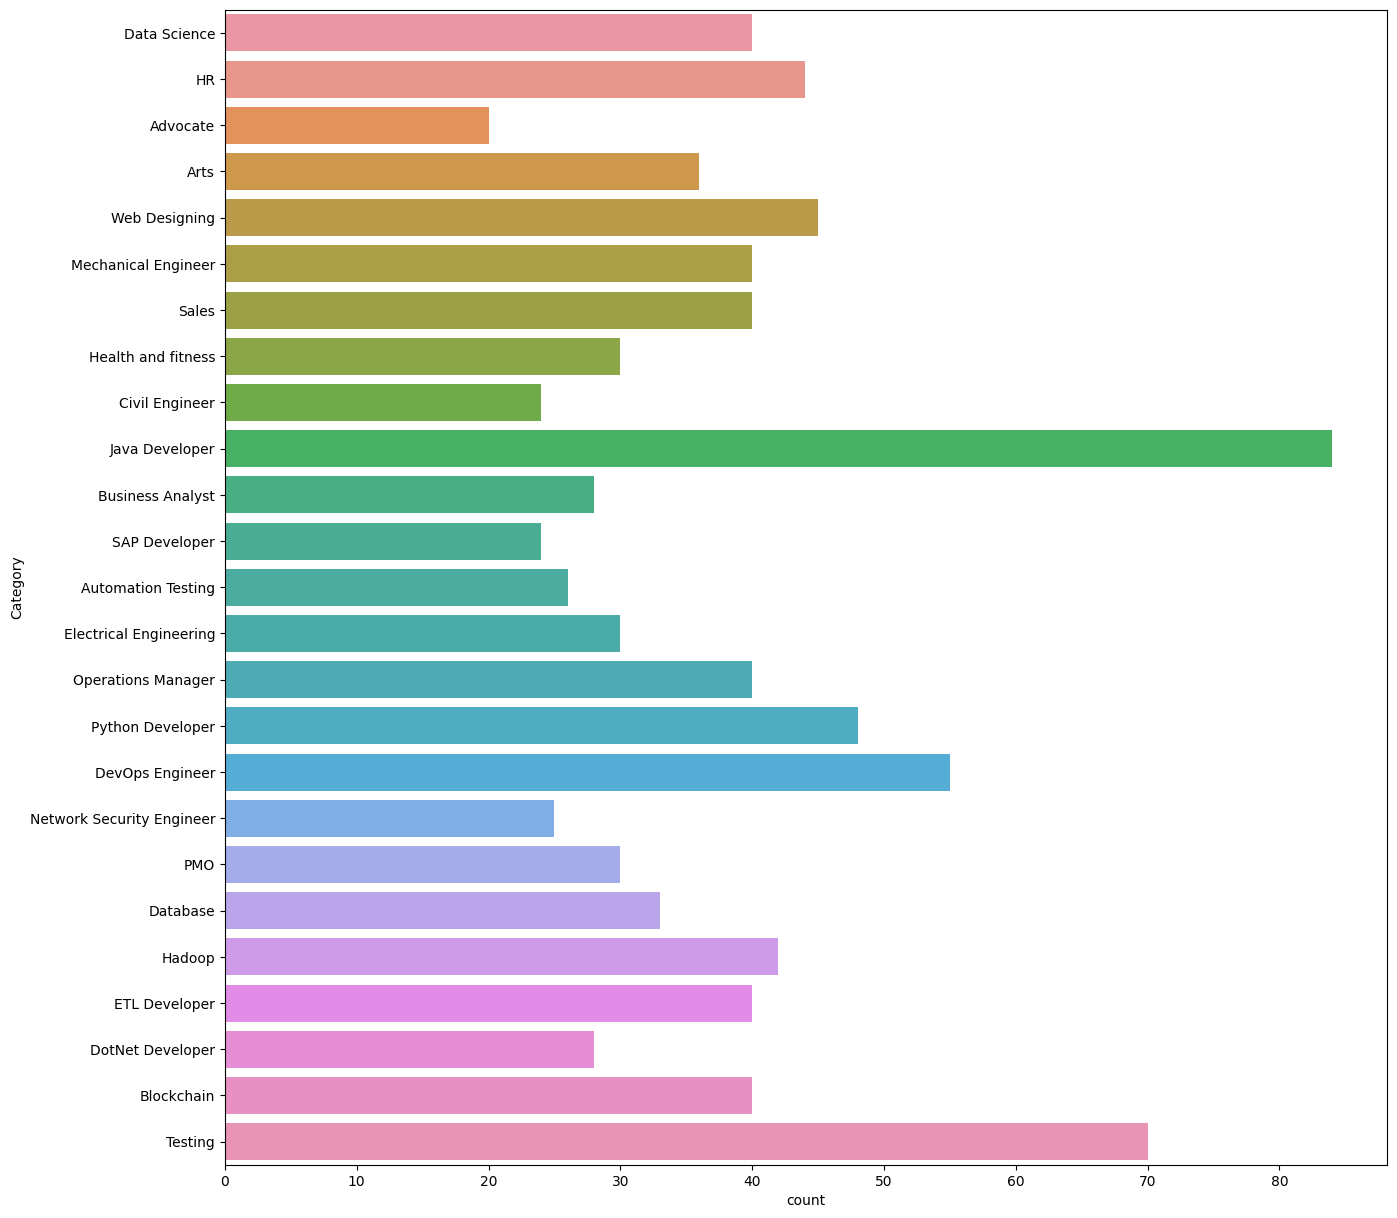

In [8]:
import seaborn as sns 
plt.figure(figsize=(15,15))
plt.xlabel("categories")
plt.ylabel("count")
sns.countplot(y='Category',data=df)

In [9]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [10]:
nltk.download("stopwords")

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [11]:
nltk.download("wordnet")

[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [12]:
import string 

In [13]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [14]:
a = df.Category.value_counts()
b = df.Category.unique()


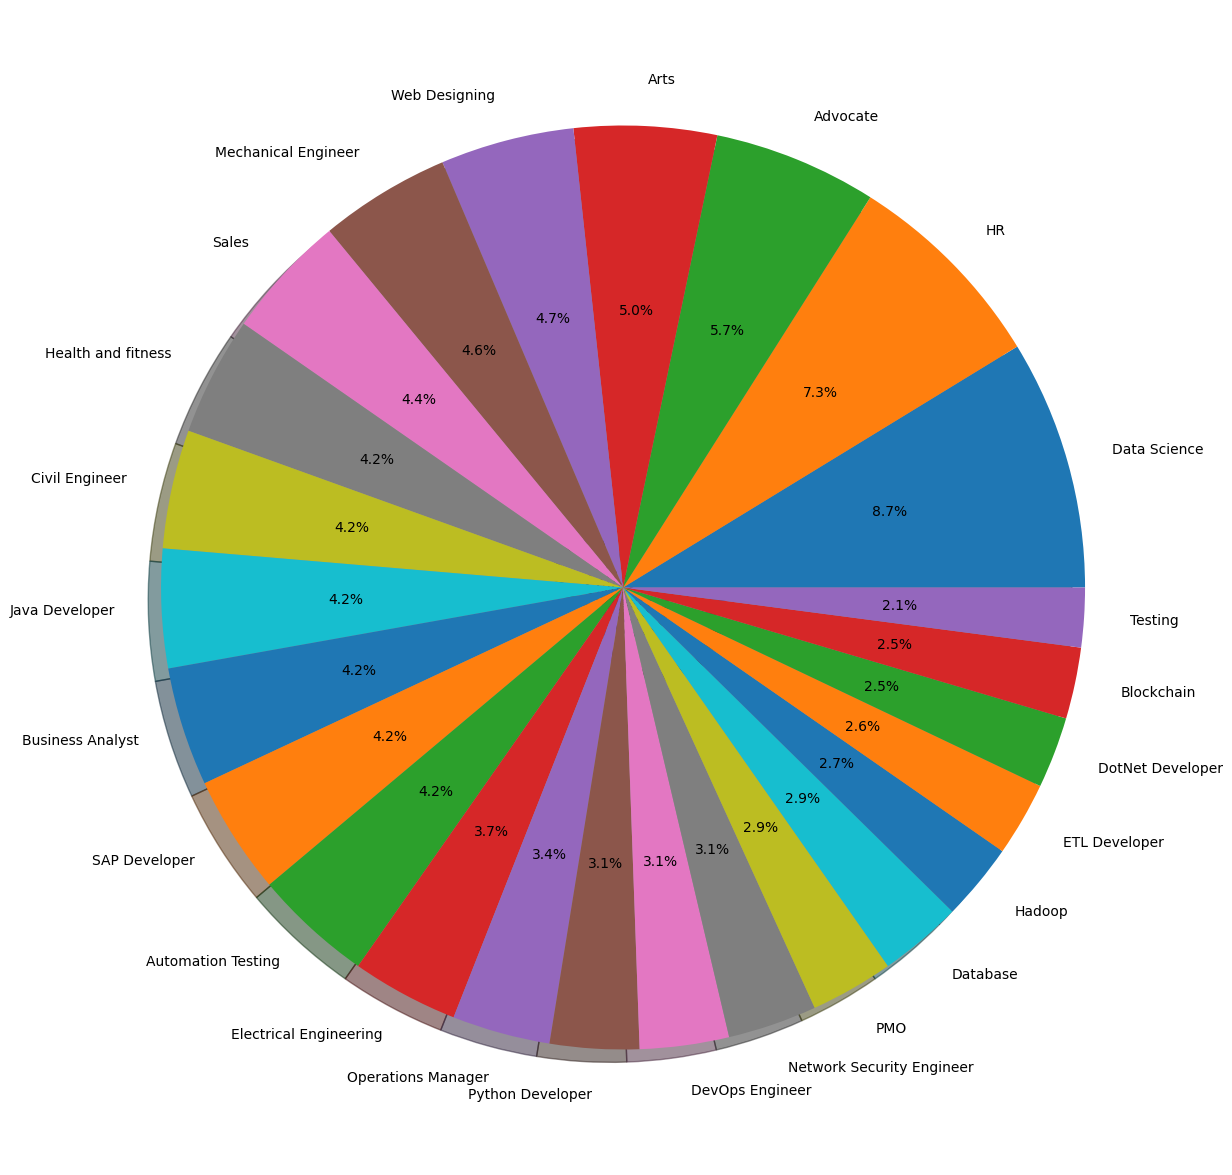

In [15]:
plt.figure(figsize=(15,15))
plt.pie(a, labels=b,autopct='%1.1f%%',shadow=True)
plt.show()

In [16]:
import string 
k = string.punctuation
k

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [17]:
import re

In [18]:
lemma = WordNetLemmatizer()
corpus = []
for i in range(0,len(df)):
    review = re.sub('http\S+\s*', ' ', df['Resume'][i])  # remove URLs
    review = re.sub('RT|cc', ' ', review)  # remove RT and cc
    review = re.sub('#\S+', '', review)  # remove hashtags
    review = re.sub('@\S+', '  ', review)  # remove mentions
    review = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', review)  # remove punctuations
    review = re.sub(r'[^\x00-\x7f]',r' ', review) 
    review = re.sub('\s+', ' ', review)  # remove extra whitespace
    review = review.lower()
    review = review.split()
    review = [lemma.lemmatize(word)  for word in review if not word in stopwords.words("english")]
    review = ' '.join(review)
    corpus.append(review)

In [19]:
df['Cleaned_resume'] = corpus

In [20]:
df.head()

,Category,Resume,Cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education detail may 2013 may 2017 b e uit rgp...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill r python sap hana tableau sap hana sql s...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education detail mca ymcaust faridabad haryana...


In [21]:
corpus

['skill programming language python panda numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm na bayes knn random forest decision tree boosting technique cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction topic modelling lda nmf pca neural net database visualization mysql sqlserver cassandra hbase elasticsearch d3 j dc j plotly kibana matplotlib ggplot tableau others regular expression html cs angular 6 logstash kafka python flask git docker computer vision open cv understanding deep learning education detail data science assurance associate data science assurance associate ernst young llp skill detail javascript exprience 24 month jquery exprience 24 month python exprience 24 monthscompany detail company ernst young llp description fraud investigation dispute service assurance technology assisted review tar technology assisted review assist elerating review process run analytics generate re

In [22]:
!pip install Wordcloud

In [23]:
corpus[184]

'skill language c basic java basic web technology html5 css3 bootstrap javascript jquery corel draw photoshop illustrator database mysql5 0 ide tool sublime text notepad operating system window xp window 7education detail september 2015 bachelor engineer information technology nagpur maharashtra nagpur university may 2011 hsc secondary higher secondary state board secondary june 2009 ssc secondary higher secondary maharashtra state board secondary web graphic designer web graphic designer virtuous medium point pune skill detail bootstrap exprience 24 month html5 exprience 24 month javascript exprience 24 month jquery exprience 24 month corel draw exprience 24 month adobe photoshop exprience 24 month adobe illustrator exprience 12 month css3 exprience 24 monthscompany detail company virtuous medium point description company cnc web world description internship program e sense solution pvt ltd nagpur web designing developement presented project competition innovesta 15 priyadarshini indi

In [24]:
from wordcloud import WordCloud

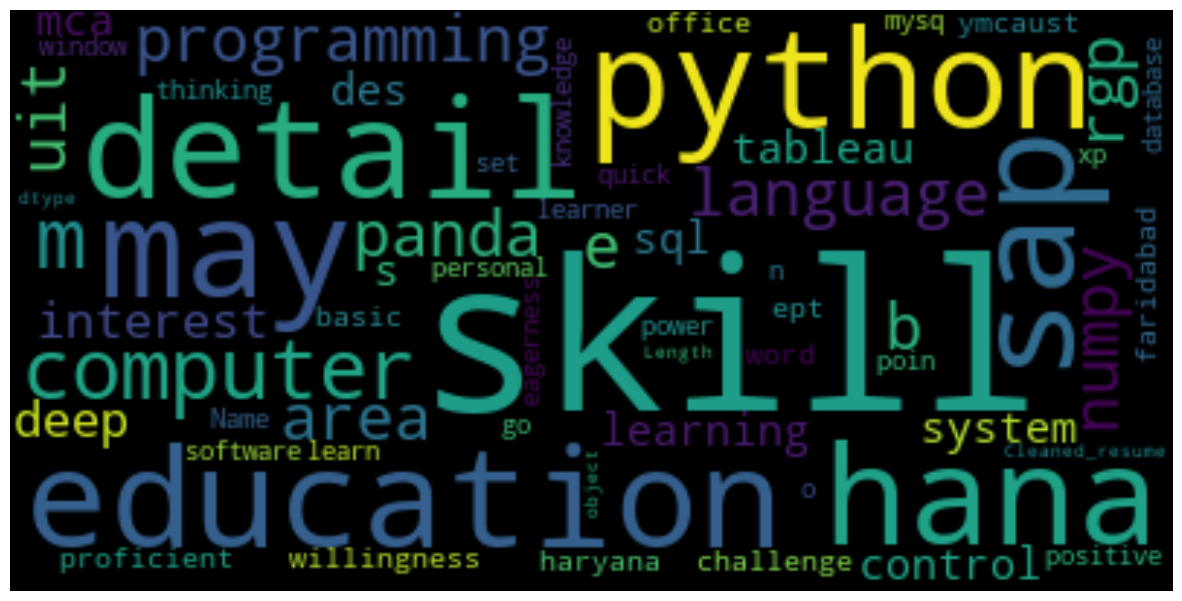

In [25]:
wc = WordCloud().generate(str(df['Cleaned_resume']))
plt.figure(figsize=(15,15))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

In [26]:
df.head()

,Category,Resume,Cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education detail may 2013 may 2017 b e uit rgp...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill r python sap hana tableau sap hana sql s...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education detail mca ymcaust faridabad haryana...


In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
label = LabelEncoder()
df['Target'] = label.fit_transform(df['Category'])

In [29]:
df.head()

,Category,Resume,Cleaned_resume,Target
0,Data Science,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...,6
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education detail may 2013 may 2017 b e uit rgp...,6
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...,6
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill r python sap hana tableau sap hana sql s...,6
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education detail mca ymcaust faridabad haryana...,6


In [30]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [31]:
df['Target'].unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [32]:
for i in range(len(df)):
    print(df['Category'][i],'----------->',df['Target'][i])

Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -----------> 6
Data Science -------

In [33]:
dep = {"Data science" : 6,
     "HR":12,
     "Advocate" : 0,
     "Arts" : 1,
     "Web designing" : 24,
     "Mechanical Engineer" : 16,
     "Sales" : 22,
     "Health and fitness" : 14,
     "Civil Engineer" : 5,
     "Java Developer" : 15,
     "Business Analyst" : 4,
     "SAP Developer" : 21,
     "Automation Testing" : 2,
     "Electrical Engineering" : 11,
     "Operations Manager" : 18,
     "Python Developer" : 20,
     "DevOps Engineer" : 8,
     "Network Security Engineer" : 17,
     "PMO" : 19,
     "Database" : 7,
     "Hadoop" : 13,
     "ETL Developer" : 10,
     "DotNet Developer" : 9,
     "Blockchain" : 3,
     "Testing" : 23
    
}

In [34]:
dep

{'Data science': 6,
 'HR': 12,
 'Advocate': 0,
 'Arts': 1,
 'Web designing': 24,
 'Mechanical Engineer': 16,
 'Sales': 22,
 'Health and fitness': 14,
 'Civil Engineer': 5,
 'Java Developer': 15,
 'Business Analyst': 4,
 'SAP Developer': 21,
 'Automation Testing': 2,
 'Electrical Engineering': 11,
 'Operations Manager': 18,
 'Python Developer': 20,
 'DevOps Engineer': 8,
 'Network Security Engineer': 17,
 'PMO': 19,
 'Database': 7,
 'Hadoop': 13,
 'ETL Developer': 10,
 'DotNet Developer': 9,
 'Blockchain': 3,
 'Testing': 23}

In [35]:
len(a)

25

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
text = df['Cleaned_resume']
target = df['Target']

In [38]:
tf = TfidfVectorizer()

In [39]:
data = tf.fit_transform(text).toarray()

In [40]:
data.shape

(962, 6678)

In [41]:
data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [42]:
X_train,X_test,y_train,y_test = train_test_split(data,target,random_state=42, test_size=0.2)

In [43]:
X_train

array([[0.05522992, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.01819369, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [44]:
X_test

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04961778, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [45]:
y_train.head()

468     2
857     3
549    18
280    14
109     1
Name: Target, dtype: int32

In [46]:
y_test.head()

344    15
381    15
351    15
778    13
277    14
Name: Target, dtype: int32

In [47]:
print(X_train.shape)
print(y_train.shape)

(769, 6678)
(769,)


In [48]:
from sklearn.naive_bayes import MultinomialNB
reg = MultinomialNB()

In [49]:
reg.fit(X_train,y_train)

MultinomialNB()

In [50]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [51]:
y_train_pred = reg.predict(X_train)


In [52]:
print(accuracy_score(y_train,y_train_pred))

0.9726918075422627


In [53]:
y_test_pred = reg.predict(X_test)

In [54]:
print(accuracy_score(y_test,y_test_pred))

0.9637305699481865


In [55]:
print(confusion_matrix(y_test,y_test_pred))

[[ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3
   0]
 [ 0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 11

In [56]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      0.67      0.80         9
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         8
           8       1.00      0.93      0.96        14
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12       1.00      0.92      0.96        12
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         7
          15       0.83      1.00      0.91        15
          16       1.00      1.00      1.00         8
          17       1.00    

### Saving our model 

In [57]:
import pickle 


In [58]:
with open("./model.pkl","wb") as f:
    pickle.dump(reg,f)

In [59]:
m = pickle.load(open('./model.pkl','rb'))


### Testing with Real Data

In [60]:
X_train

array([[0.05522992, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.01819369, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [61]:
y_train

468     2
857     3
549    18
280    14
109     1
       ..
106     1
270    14
860     3
435    21
102     0
Name: Target, Length: 769, dtype: int32

In [62]:
a = X_train[1]

In [63]:
a

array([0., 0., 0., ..., 0., 0., 0.])

In [64]:
reg.predict([a])

array([3])

In [65]:
y_train

468     2
857     3
549    18
280    14
109     1
       ..
106     1
270    14
860     3
435    21
102     0
Name: Target, Length: 769, dtype: int32

In [66]:
import pickle

In [67]:
with open('count.pkl','wb') as f:
    pickle.dump(tf,f)

In [68]:
year = 2017
if (year % 400 == 0) and (year % 100 == 0):
    print("{0} is a leap year".format(year))
elif (year % 4 ==0) and (year % 100 != 0):
    print("{0} is a leap year".format(year))

In [69]:
import sklearn

In [70]:
print(sklearn.__version__)

1.2.0


### Extract text from doc files for checking 

In [71]:
import pytesseract

In [72]:
!pip install python-docx

In [73]:
from docx import Document

document = Document('./senior-java-developer-1548174801.docx')
print(document.paragraphs)

[<docx.text.paragraph.Paragraph object at 0x0000027CFB93F310>, <docx.text.paragraph.Paragraph object at 0x0000027CFB93FBE0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB9504F0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB950460>, <docx.text.paragraph.Paragraph object at 0x0000027CFB950490>, <docx.text.paragraph.Paragraph object at 0x0000027CFB9507F0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB9505B0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB9505E0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB950640>, <docx.text.paragraph.Paragraph object at 0x0000027CFB9506A0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB950700>, <docx.text.paragraph.Paragraph object at 0x0000027CFB950760>, <docx.text.paragraph.Paragraph object at 0x0000027CFB9507C0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB950820>, <docx.text.paragraph.Paragraph object at 0x0000027CFB9508B0>, <docx.text.paragraph.Paragraph object at 0x0000027CFB950970>, <docx.t

In [74]:
sum1 = ''
for p in document.paragraphs:
    sum1+=p.text

### Conditions loop for clean the data for Test 

In [75]:
sum1

'Robert SmithSr. Java DeveloperPERSONAL STATEMENTSr. Java Developer with 7+ years of experience in analysis, design, implementation, and testing of Web/Enterprise applications in the Client/Server environment using Java/J2EE technologies. Expertise in designing and developing applications in Java/J2EE environment using JSPs, Servlets, JDBC, JavaBeans, Struts 2.x/1.3, Spring 3.x/2.x, Hibernate 3.0, XML, JUnit, Log4j, CSS, Apache Tomcat Server, IBM WebSphere Server, JBoss, BEA WebLogic Server, JavaScript, Oracle, MySQL.WORK EXPERIENCESr. Java DeveloperMarriot International -\tOctober 2011 – PresentResponsibilities:Involved in the review and analysis of the functional specifications, and requirements clarification defects etc.Involved in the analysis and design of the initiatives using rational application developer.Involved in the development of the user interfaces using HTML, JSP, JS, J-Query, CSS, and Ajax.Involved in the presentation tier design as well as the services layer, and prep

In [76]:
lemma = WordNetLemmatizer()
p = []
review = re.sub('http\S+\s*', ' ',sum1)  # remove URLs
review = re.sub('RT|cc', ' ', review)  # remove RT and cc
review = re.sub('#\S+', '', review)  # remove hashtags
review = re.sub('@\S+', '  ', review)  # remove mentions
review = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', review)  # remove punctuations
review = re.sub(r'[^\x00-\x7f]',r' ', review) 
review = re.sub('\s+', ' ', review)  # remove extra whitespace
review = review.lower()
review = review.split()
review = [lemma.lemmatize(word)  for word in review if not word in stopwords.words("english")]
review = ' '.join(review)
p.append(review)

In [77]:
p[0]

'robert smithsr java developerpersonal statementsr java developer 7 year experience analysis design implementation testing web enterprise application client server environment using java j2ee technology expertise designing developing application java j2ee environment using jsps servlets jdbc javabeans strut 2 x 1 3 spring 3 x 2 x hibernate 3 0 xml junit log4j cs apache tomcat server ibm websphere server jboss bea weblogic server javascript oracle mysql work experiencesr java developermarriot international october 2011 presentresponsibilities involved review analysis functional specification requirement clarification defect etc involved analysis design initiative using rational application developer involved development user interface using html jsp j j query cs ajax involved presentation tier design well service layer prepared class diagram sequence diagram redpath enhancement involved design presentation tier service layer etc initiative prepared technical design document presentation

In [78]:
l = tf.transform(p).toarray()

In [79]:
l

array([[0., 0., 0., ..., 0., 0., 0.]])

In [80]:
l.shape

(1, 6678)

In [81]:
X_train[0].shape

(6678,)

In [82]:
X_train[0]

array([0.05522992, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ])

In [83]:
sol = reg.predict(l)
sol

array([15])

In [84]:
for i , j in dep.items():
    if j == sol:
        print(i)

Java Developer


### Mobile Number Extracting 

In [85]:
import re
regu =re.findall(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]',sum1)
regu

[]

### Mail_id Extracting 

In [86]:
emails = re.findall(r"[a-z0-9\.\-+_]+@[a-z0-9\.\-+_]+\.[a-z]+",sum1)
print(emails)


[]


In [87]:
results = {"Mobile_Number ": regu ,
          "Mail_id" : emails}
results

{'Mobile_Number ': [], 'Mail_id': []}

### Extracting Skills 

In [88]:
import docx2txt
import nltk
 
nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [89]:
# you may read the database from a csv file or some other database
SKILLS_DB = []
ch = ['c','c++','java','.NET c#','python','ruby','php','html','css','javascript','node js','react js','django','flask','apache',
     
     'hadoop','big data','data science','numpy','pandas','machine learning','deep learning','statistics','nlp','natural language processing'
     
     'open cv','compter vision','devops','aws','azure','microsoft azure','google cloud','rest api','graphql','react','react native',
     
     'sql','postgresql','git','redis','jira','selenium','jquery','bootstrap','mongodb']
for i in ch:
    SKILLS_DB.append(i.lower())
    
def extract_text_from_docx(docx_path):
    txt = docx2txt.process(docx_path)
    if txt:
        return txt.replace('\t', ' ')
    return None
 
def extract_skills(input_text):
    input_text = input_text.lower()
    stop_words = set(nltk.corpus.stopwords.words('english'))
    word_tokens = nltk.tokenize.word_tokenize(input_text)
 
    # remove the stop words
    filtered_tokens = [w for w in word_tokens if w not in stop_words]
 
    # remove the punctuation
    filtered_tokens = [w for w in word_tokens if w.isalpha()]
 
    # generate bigrams and trigrams (such as artificial intelligence)
    bigrams_trigrams = list(map(' '.join, nltk.everygrams(filtered_tokens, 2, 3)))
 
    # we create a set to keep the results in.
    found_skills = set()
 
    # we search for each token in our skills database
    for token in filtered_tokens:
        if token.lower() in SKILLS_DB:
            found_skills.add(token)
 
    # we search for each bigram and trigram in our skills database
    for ngram in bigrams_trigrams:
        if ngram.lower() in SKILLS_DB:
            found_skills.add(ngram)
 
    return found_skills
 
 
if __name__ == '__main__':
    text = extract_text_from_docx('./senior-java-developer-1548174801.docx')
    skills = extract_skills(text)
    print(skills)
 

 

{'apache', 'javascript', 'java', 'html', 'css'}


### Extracting Name 

In [90]:
import docx2txt
import docx2txt
import nltk
 
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [Errno 11001] getaddrinfo failed>
[nltk_data] Error loading maxent_ne_chunker: <urlopen error [Errno
[nltk_data]     11001] getaddrinfo failed>
[nltk_data] Error loading words: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [91]:
import spacy
from spacy.matcher import Matcher

In [92]:
# load pre-trained model
nlp = spacy.load('en_core_web_sm')

# initialize matcher with a vocab
matcher = Matcher(nlp.vocab)

def extract_name(resume_text):
    nlp_text = nlp(resume_text)
    
    # First name and Last name are always Proper Nouns
    pattern = [{'POS': 'PROPN'}, {'POS': 'PROPN'}]
    
    matcher.add('NAME', [pattern])
    
    matches = matcher(nlp_text)
    
    for match_id, start, end in matches:
        span = nlp_text[start:end]
        return span.text
extract_name(sum1)

'Robert SmithSr'

### Complete Loop 

In [93]:
import pickle 

In [94]:
with open("./model.pkl","wb") as f:
    pickle.dump(reg,f)

In [95]:
model = pickle.load(open('./model.pkl','rb'))


In [96]:
pip install PyPDF2

Note: you may need to restart the kernel to use updated packages.


In [97]:
SKILLS_DB = []
ch = ['c','c++','java','.NET c#','python','ruby','php','html','css','javascript','node js','react js','django','flask','apache',

'hadoop','big data','data science','numpy','pandas','machine learning','deep learning','statistics','nlp','natural language processing'

'open cv','compter vision','devops','aws','azure','microsoft azure','google cloud','rest api','graphql','react','react native',

'sql','postgresql','git','redis','jira','selenium','jquery','bootstrap','mongodb','UI KIT','Swift','github','xcode']
for i in ch:
    SKILLS_DB.append(i.lower())


### Only for docx files 

In [98]:
def complete_logic(resume1):
    from PyPDF2 import PdfFileReader, PdfFileWriter
    import fitz
    resume=''
    from docx import Document
    if resume1.endswith('.docx'):
        resume = resume1
    elif resume1.endswith('.pdf'):
        complete_text=''
        with fitz.open(resume1) as doc:
            for page in doc:
                complete_text += page.get_text()


        
        

    resume_text = Document(resume)
    complete_text = ''
    for p in resume_text.paragraphs:
        complete_text+=p.text
    # Cleaning Incoming Data 
    lemma = WordNetLemmatizer()
    p = []
    review = re.sub('http\S+\s*', ' ',complete_text)  # remove URLs
    review = re.sub('RT|cc', ' ', review)  # remove RT and cc
    review = re.sub('#\S+', '', review)  # remove hashtags
    review = re.sub('@\S+', '  ', review)  # remove mentions
    review = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', review)  # remove punctuations
    review = re.sub(r'[^\x00-\x7f]',r' ', review) 
    review = re.sub('\s+', ' ', review)  # remove extra whitespace
    review = review.lower()
    review = review.split()
    review = [lemma.lemmatize(word)  for word in review if not word in stopwords.words("english")]
    review = ' '.join(review)
    p.append(review)
    l = tf.transform(p).toarray()
    # Loading Model 
    sol = model.predict(l)
    for i , j in dep.items():
        if j == sol:
            print("Category of Resume belongs to = ",i)
    regu =re.findall(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]',complete_text)
    print('------------------*--------------------')
    print('Mobile Number = ',regu)
    emails = re.findall(r"[a-z0-9\.\-+_]+@[a-z0-9\.\-+_]+\.[a-z]+",complete_text)
    print('-------------------*--------------------')
    print("Email = ",emails)
    print("-------------------*-----------------------")
    ## Extract name
    nlp = spacy.load('en_core_web_sm')

    # initialize matcher with a vocab
    matcher = Matcher(nlp.vocab)
    nlp_text = nlp(complete_text)
    
    # First name and Last name are always Proper Nouns
    pattern = [{'POS': 'PROPN'}, {'POS': 'PROPN'}]
    
    matcher.add('NAME', [pattern])
    
    matches = matcher(nlp_text)
    
    for match_id, start, end in matches:
        span = nlp_text[start:end]
    print("Name = ",span.text)
    print('--------------------*-------------')
    
    # Extracting skills 
    
    import docx2txt
    sk = docx2txt.process(resume)
    if sk:
        a4 = sk.replace('\t',' ')
    input_text = a4.lower()
    stop_words = set(nltk.corpus.stopwords.words('english'))
    word_tokens = nltk.tokenize.word_tokenize(input_text)

    # remove the stop words
    filtered_tokens = [w for w in word_tokens if w not in stop_words]

    # remove the punctuation
    filtered_tokens = [w for w in word_tokens if w.isalpha()]

    # generate bigrams and trigrams (such as artificial intelligence)
    bigrams_trigrams = list(map(' '.join, nltk.everygrams(filtered_tokens, 2, 3)))

    # we create a set to keep the results in.
    found_skills = set()
        
    # we search for each token in our skills database
    for token in filtered_tokens:
        if token.lower() in SKILLS_DB:
            found_skills.add(token)

    # we search for each bigram and trigram in our skills database
    for ngram in bigrams_trigrams:
        if ngram.lower() in SKILLS_DB:
            found_skills.add(ngram)

    print("Skills = ",found_skills)



### For Docx and PDF files 

In [99]:
def complete_logic(resume1):
    from PyPDF2 import PdfFileReader, PdfFileWriter
    import fitz
    resume=''
    from docx import Document
    if resume1.endswith('.docx'):
        resume = resume1
         # Cleaning Incoming Data 
        resume_text = Document(resume)
        complete_text = ''
        for p in resume_text.paragraphs:
            complete_text+=p.text
        
        lemma = WordNetLemmatizer()
        p = []
        review = re.sub('http\S+\s*', ' ',complete_text)  # remove URLs
        review = re.sub('RT|cc', ' ', review)  # remove RT and cc
        review = re.sub('#\S+', '', review)  # remove hashtags
        review = re.sub('@\S+', '  ', review)  # remove mentions
        review = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', review)  # remove punctuations
        review = re.sub(r'[^\x00-\x7f]',r' ', review) 
        review = re.sub('\s+', ' ', review)  # remove extra whitespace
        review = review.lower()
        review = review.split()
        review = [lemma.lemmatize(word)  for word in review if not word in stopwords.words("english")]
        review = ' '.join(review)
        p.append(review)
        l = tf.transform(p).toarray()
        # Loading Model 
        sol = model.predict(l)
        for i , j in dep.items():
            if j == sol:
                print("Category of Resume belongs to = ",i)
        regu =re.findall(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]',complete_text)
        print('------------------*--------------------')
        print('Mobile Number = ',regu)
        emails = re.findall(r"[a-z0-9\.\-+_]+@[a-z0-9\.\-+_]+\.[a-z]+",complete_text)
        print('-------------------*--------------------')
        print("Email = ",emails)
        print("-------------------*-----------------------")
        a = re.findall(r"(\d+(?:\.\d+)?).?\s?year.?",complete_text)
        print("Total years of experience = ",a[0],'years')
        print('-------------------*------------------------')
        ## Extract name
        nlp = spacy.load('en_core_web_sm')

        # initialize matcher with a vocab
        matcher = Matcher(nlp.vocab)
        nlp_text = nlp(complete_text)

        # First name and Last name are always Proper Nouns
        pattern = [{'POS': 'PROPN'}, {'POS': 'PROPN'}]

        matcher.add('NAME', [pattern])

        matches = matcher(nlp_text)

        for match_id, start, end in matches:
             span = nlp_text[start:end]
        print("Name = ",span.text)
        print('--------------------*-------------')

         # Extracting skills 

        import docx2txt
        sk = docx2txt.process(resume)
        if sk:
            a4 = sk.replace('\t',' ')
        input_text = a4.lower()
        stop_words = set(nltk.corpus.stopwords.words('english'))
        word_tokens = nltk.tokenize.word_tokenize(input_text)

        # remove the stop words
        filtered_tokens = [w for w in word_tokens if w not in stop_words]

        # remove the punctuation
        filtered_tokens = [w for w in word_tokens if w.isalpha()]

        # generate bigrams and trigrams (such as artificial intelligence)
        bigrams_trigrams = list(map(' '.join, nltk.everygrams(filtered_tokens, 2, 3)))

        # we create a set to keep the results in.
        found_skills = set()

        # we search for each token in our skills database
        for token in filtered_tokens:
            if token.lower() in SKILLS_DB:
                found_skills.add(token)

        # we search for each bigram and trigram in our skills database
        for ngram in bigrams_trigrams:
            if ngram.lower() in SKILLS_DB:
                found_skills.add(ngram)

        print("Skills = ",found_skills)


    elif resume1.endswith('.pdf'):
        complete_text=''
        with fitz.open(resume1) as doc:
            for page in doc:
                complete_text += page.get_text()  
        # Cleaning Incoming Data 
        lemma = WordNetLemmatizer()
        p = []
        review = re.sub('http\S+\s*', ' ',complete_text)  # remove URLs
        review = re.sub('RT|cc', ' ', review)  # remove RT and cc
        review = re.sub('#\S+', '', review)  # remove hashtags
        review = re.sub('@\S+', '  ', review)  # remove mentions
        review = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', review)  # remove punctuations
        review = re.sub(r'[^\x00-\x7f]',r' ', review) 
        review = re.sub('\s+', ' ', review)  # remove extra whitespace
        review = review.lower()
        review = review.split()
        review = [lemma.lemmatize(word)  for word in review if not word in stopwords.words("english")]
        review = ' '.join(review)
        p.append(review)
        l = tf.transform(p).toarray()
        # Loading Model 
        sol = model.predict(l)
        for i , j in dep.items():
            if j == sol:
                print("Category of Resume belongs to = ",i)
        regu =re.findall(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]',complete_text)
        print('------------------*--------------------')
        print('Mobile Number = ',regu)
        emails = re.findall(r"[a-z0-9\.\-+_]+@[a-z0-9\.\-+_]+\.[a-z]+",complete_text)
        print('-------------------*--------------------')
        print("Email = ",emails)
        print("-------------------*-----------------------")
        a = re.findall(r"(\d+(?:\.\d+)?).?\s?year.?",complete_text)
        print("Total years of experience = ",a[0],'years')
        print('-------------------*------------------------')

        ## Extract name
        nlp = spacy.load('en_core_web_sm')

        # initialize matcher with a vocab
        matcher = Matcher(nlp.vocab)
        nlp_text = nlp(complete_text)

        # First name and Last name are always Proper Nouns
        pattern = [{'POS': 'PROPN'}, {'POS': 'PROPN'}]

        matcher.add('NAME', [pattern])

        matches = matcher(nlp_text)

        for match_id, start, end in matches:
            span = nlp_text[start:end]
        print("Name = ",span.text)
        print('--------------------*-------------')

        # Extracting skills 

        
        input_text = complete_text.lower()
        stop_words = set(nltk.corpus.stopwords.words('english'))
        word_tokens = nltk.tokenize.word_tokenize(input_text)

        # remove the stop words
        filtered_tokens = [w for w in word_tokens if w not in stop_words]

        # remove the punctuation
        filtered_tokens = [w for w in word_tokens if w.isalpha()]

        # generate bigrams and trigrams (such as artificial intelligence)
        bigrams_trigrams = list(map(' '.join, nltk.everygrams(filtered_tokens, 2, 3)))

        # we create a set to keep the results in.
        found_skills = set()

        # we search for each token in our skills 
        for token in filtered_tokens:
            if token.lower() in SKILLS_DB:
                found_skills.add(token)

        # we search for each bigram and trigram in our skills 
        for ngram in bigrams_trigrams:
            if ngram.lower() in SKILLS_DB:
                found_skills.add(ngram)

        print("Skills = ",found_skills)
        
        



In [100]:
complete_logic('./kamal e resume - Copy.pdf')

Category of Resume belongs to =  Data science
------------------*--------------------
Mobile Number =  ['7207129751']
-------------------*--------------------
Email =  ['saikamal9797@gmail.com']
-------------------*-----------------------
Total years of experience =  2 years
-------------------*------------------------
Name =  Sai Kamal
--------------------*-------------
Skills =  {'flask', 'python', 'github', 'nlp', 'machine learning', 'deep learning', 'c', 'java', 'django', 'html', 'css'}


In [101]:
complete_logic('./shreyas-gerdau-sr-manager.docx')

Category of Resume belongs to =  Data science
------------------*--------------------
Mobile Number =  ['8332812827']
-------------------*--------------------
Email =  ['srinivasbhuduru@gmail.com']
-------------------*-----------------------
Total years of experience =  7 years
-------------------*------------------------
Name =  Srinivas Bhuduru
--------------------*-------------
Skills =  {'flask', 'numpy', 'apache', 'python', 'nlp', 'statistics', 'machine learning', 'big data', 'data science', 'deep learning', 'c', 'rest api', 'django', 'google cloud', 'aws', 'pandas', 'azure'}


In [102]:
complete_logic('./Robert Smith 1.pdf')

Category of Resume belongs to =  Java Developer
------------------*--------------------
Mobile Number =  []
-------------------*--------------------
Email =  []
-------------------*-----------------------
Total years of experience =  7 years
-------------------*------------------------
Name =  ABC Corp
--------------------*-------------
Skills =  {'apache', 'javascript', 'java', 'html', 'css'}


In [103]:
a = 'Hello world!'
a = a[::-1]
b = '!dlqow olfeH'
count=0
for i in range(len(a)):
    if a[i] != b[i]:
        count+=1
print(count)

2


In [104]:
a='kamal'
d=[ord(i) for i in a]
print(sum([j for j in d if j % 2 != 0]))


410


In [105]:
s = 'abcdefg'
d = s[::-1]
d[::2]


'geca'

In [106]:
width = 4
height = 4
for i in range(width):
    print('*',end='')
for j in range(height):
    print('*')
for i in range(width):
    print('*',end='')
for i in range(width):
    
    
    

IndentationError: expected an indented block (196750841.py, line 12)

In [ ]:
width = 4
height = 4
for i in range(width):
    for j in range(height):
        if i == 0 or i == width-1 or j==0 or j == height-1:
            print('*',end='')
        else:
            print(' ',end=' ')
    print('')

In [ ]:

a = '11'
print(sum([int(i) for i in a]))

In [ ]:
a = '11'
sum = 0
for i in a:
    sum+=int(i)
print(sum**sum)

In [ ]:
a = ['doc','docx','pdf']
print('pdf' in a)

In [ ]:
b = 'kamal e resume.docx'

In [ ]:
c = []
extensions = ['docx','pdf']
for i in extensions:
    if i in b:
        c.append(i)
print(c[0])

In [ ]:
a = 'ka'

a*4

In [ ]:
n=int(input())
s=0
for i in range(n):
    if i%3==0 or i%5==0 or i%7==0:
        s+=i
print(s)




In [ ]:
print(sum([i for i in range(int(input())) if i%3 == 0 or i%5== 0 or i%7 == 0]))

In [ ]:
int((20 / 100)  * 100)

In [ ]:
g='M'
w=100
if g=='F':print(w+int((20/100)*100))
elif g=='M':print(w)
else:print('UNKNOWN')


In [ ]:
a = 5
if a % 2 == 0:
    for i in range(a):
        print(a*'*')
else:
    k = 2*a-2
    for i in range(0,a):
        for j in range(0,k):
            print(end=' ')
        k = k-2
        for j in range(0,i+1):
            print('*',end='')
        print()



In [ ]:
k = 2*n - 2
 
    # outer loop to handle number of rows
    for i in range(0, n):
     
        # inner loop to handle number spaces
        # values changing acc. to requirement
        for j in range(0, k):
            print(end=" ")
     
        # decrementing k after each loop
        k = k - 2
     
        # inner loop to handle number of columns
        # values changing acc. to outer loop
        for j in range(0, i+1):
         
            # printing stars
            print("* ", end="")
     
        # ending line after each row
        print("\r")

In [ ]:
a = 5
for i in range(a):
    for j in range(a):
        print(end=" ")
    a = a - 2
    for j in range(0, i+1):
        print("* ", end="")
    print()

In [ ]:
a = 5
for i in range(1,a):
    print(' '*a+i*'*')
    a-=1

In [ ]:
filename = 'kamal ex resume.docx'
extensions = ['docx','pdf']
c = []
d = []
for i in extensions:
    if i in filename:
        d.append(i)
        c.append(filename.index(i))

k = c[0]
filename = filename[:k]
print(filename)
print(d[0])
print(filename+d[0])

In [ ]:
a = 'kamal ex resume.docx'
b = a.index('docx')
print(b)
a[:16]

In [ ]:
a='kamal.pdf'
a.index('pdf')
print(a[6:])

In [ ]:
a = [12]
a.insert